#COLLEGE PREDICTOR

IMPORTING ALL THE LIBRARIES.

In [167]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

ABOUT DATASET: Various datasets have been used in this project, it contains information about the Engineering Colleges like, COLLEGE NAME, CAMPUS SIZE, RATING, COURSES OFFERED, FACILITIES,STATE, AVERAGE COLLEGE FEES and few more details.There is also a dataset that shows different colleges for MASTER'S DEGREE PROGRAM and GATE SCORE required to get admission in those colleges.


TITLE OF PROJECT:  COLLEGE PREDICTOR
(Subject Line)

AIM: Students face a lot of problems in looking for colleges after 12th. So this college predictor will help them in choosing colleges as per their choice if they performed well in entrance exam. This model also helps a student in selecting college for the MASTER'S DEGREE PROGRAM as per their GATE SCORE. This is beacuse you only commit a mistake once in life.

In [168]:
data=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PROJECT_DATA.csv")
data1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/gate_applicants.csv")

CLEANING DATA(ABOUT ENGINEERING COLLEGES)

In [169]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5446 entries, 0 to 5445
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   College Name               5446 non-null   object
 1   Genders Accepted           5428 non-null   object
 2   Campus Size                2695 non-null   object
 3   Total Student Enrollments  4443 non-null   object
 4   Total Faculty              5285 non-null   object
 5   Established Year           5345 non-null   object
 6   Rating                     333 non-null    object
 7   University                 3510 non-null   object
 8   Courses                    5446 non-null   object
 9   Facilities                 5434 non-null   object
 10  City                       5446 non-null   object
 11  State                      5446 non-null   object
 12  Country                    5446 non-null   object
 13  College Type               5445 non-null   object
 14  Average 

LOOKING FOR THE NULL VALUES IN DATASET AS IT MAKES THE DATA INCONSISTENT.

In [170]:
data.apply(lambda x:sum(x.isnull()),axis=0)

College Name                    0
Genders Accepted               18
Campus Size                  2751
Total Student Enrollments    1003
Total Faculty                 161
Established Year              101
Rating                       5113
University                   1936
Courses                         0
Facilities                     12
City                            0
State                           0
Country                         0
College Type                    1
Average Fees                    0
dtype: int64

REPLACING ALL THE NULL VALUES IN THE COLUMN

In [171]:
data['Rating'] = data[['Rating']].fillna(0)

In [172]:
data['College Type'] = data[['College Type']].fillna(0)

In [173]:
data['Total Student Enrollments'] = data[['Total Student Enrollments']].fillna(0)

In [174]:
data['Total Faculty'] = data[['Total Faculty']].fillna(0)

In [175]:
data["Rating"].replace({"Rating": 0}, inplace=True)

In [176]:
data["College Type"].replace({0: "Private"}, inplace=True)

In [177]:
data['Rating'] = data[['Rating']].astype(float)

In [178]:
data["Average Fees"].replace({"Average Fees": 0}, inplace=True)

In [179]:
data['Average Fees'] = data[['Average Fees']].astype(float)

In [180]:
data['Average Fees']=data['Average Fees'].round(decimals = 2)

In [181]:
data['University'] = data[['University']].fillna(0)

In [182]:
data["University"].replace({0:"No University"}, inplace=True)

In [183]:
data.head()

,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,Rating,University,Courses,Facilities,City,State,Country,College Type,Average Fees
0,National Institute of Technology Rourkela,Co-Ed,647 Acres,4811,329,2007,3.12,No University,"B.Tech Mechanical Engineering, B.Tech Computer...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Rourkela,Odisha,India,Public/Government,350600.00
1,Visvesvaraya National Institute of Technology ...,Co-Ed,215 Acres,1071,192,2007,0.00,No University,"B.Tech Computer Science Engineering, B.Tech El...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Nagpur,Maharashtra,India,Public/Government,273596.67
2,Netaji Subhas University of Technology,Co-Ed,145 Acres,3759,101,2018,0.00,No University,"B.Tech Computer Engineering, B.Tech Electronic...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",New Delhi,Delhi,India,Public/Government,352320.00
3,Birla Institute of Technology,Co-Ed,980 Acres,4506,284,1955,0.00,No University,"B.Tech Computer Science Engineering, B.Tech El...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Ranchi,Jharkhand,India,Private,596686.05
4,International Institute of Information Technology,Co-Ed,66 Acres,1721,85,2001,3.05,No University,"B.Tech Computer Science and Engineering, M.Tec...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Hyderabad,Telangana,India,Private,756666.67


In [184]:
data.tail()

,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,Rating,University,Courses,Facilities,City,State,Country,College Type,Average Fees
5441,BES Institute of Technology,Co-Ed,4 Acres,0,31,2003,0.0,No University,"Diploma in Civil Engineering, Diploma in Compu...","Girls Hostel, Library, Sports, Cafeteria, Audi...",Bengaluru,Karnataka,India,Private,38490.0
5442,Radical Polytechnic College,Co-Ed,NaN,0,0,2013,0.0,No University,"Diploma in Civil Engineering, Diploma in Mecha...","Boys Hostel, Girls Hostel, Library, Sports, Wi...",Amritsar,Punjab,India,Private,75100.0
5443,Trimurti Institute of Technology Polytechnic,Co-Ed,NaN,22,55,2009,0.0,No University,"Diploma in Electrical Engineering, Diploma in ...","Library, Sports, IT Infrastructure, Laboratories",Paldhi,Maharashtra,India,Private,157000.0
5444,RV Parankar College of Engineering and Technology,Co-Ed,NaN,38,10,2015,0.0,Rashtrasant Tukadoji Maharaj Nagpur University...,"BE Civil Engineering, BE Electrical Engineerin...","Library, Sports, Cafeteria, Auditorium, IT Inf...",Arvi,Maharashtra,India,Private,272000.0
5445,Centre for Design Excellence,Co-Ed,NaN,0,20,NaN,0.0,"Vivekananda Global University, Jaipur","B.Arch, B.Des Fashion and Textile Design, B.De...","Boys Hostel, Girls Hostel, Library, Sports, Au...",Jaipur,Rajasthan,India,Private,897500.0


In [185]:
data.loc[data['College Type'] == 'College Type']

,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,Rating,University,Courses,Facilities,City,State,Country,College Type,Average Fees
597,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,0.0,University,Courses,Facilities,City,State,Country,College Type,0.0
1735,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,0.0,University,Courses,Facilities,City,State,Country,College Type,0.0
3622,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,0.0,University,Courses,Facilities,City,State,Country,College Type,0.0
4277,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,0.0,University,Courses,Facilities,City,State,Country,College Type,0.0
4494,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,0.0,University,Courses,Facilities,City,State,Country,College Type,0.0
4790,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,0.0,University,Courses,Facilities,City,State,Country,College Type,0.0


In [186]:
data = data.drop(labels=[597,1735,3622,4276,4277,4494,4790], axis=0)

ANALYSING WHICH STATE HAS BETTER RATED ENGINEERING COLLEGES AND WHICH STATE HAS MORE ENGINEERING COLLEGES.

Bar Graph showing RATING of college as per the COLLEGE TYPE in a particular STATE.

(Rating of the college will be visible, when you will hover over plot.)

In [187]:
px.bar(data, x = 'Rating', y = 'College Type', color = 'State',orientation='h' , title='Rating by College Type',  height = 500 )

ANALYZING WHICH COUNTRY OFFERS HOW MANY MASTER DEGREE PROGRAMS.

Arranging the countries in order as per the number of Master Degree Programs offered by them.

In [188]:
COUNTRIES=data3['country_name'].value_counts().sort_values(ascending=False)
COUNTRIES[0:20]

United States     24084
United Kingdom    14130
Australia          2932
Canada             2152
Netherlands        1346
France             1282
Germany            1053
Ireland             894
China               836
Sweden              806
Italy               756
Spain               724
Greece              700
Belgium             657
Hong Kong           542
Switzerland         482
New Zealand         472
Malaysia            457
Denmark             374
Norway              348
Name: country_name, dtype: int64

ANALYZING THE AVERAGE FEES FOR ENGINEERING.

Box plot is used here for better understanding of the column "Average Fees". It gives us idea about how much fees most of the colleges and universities charge for Engineering.

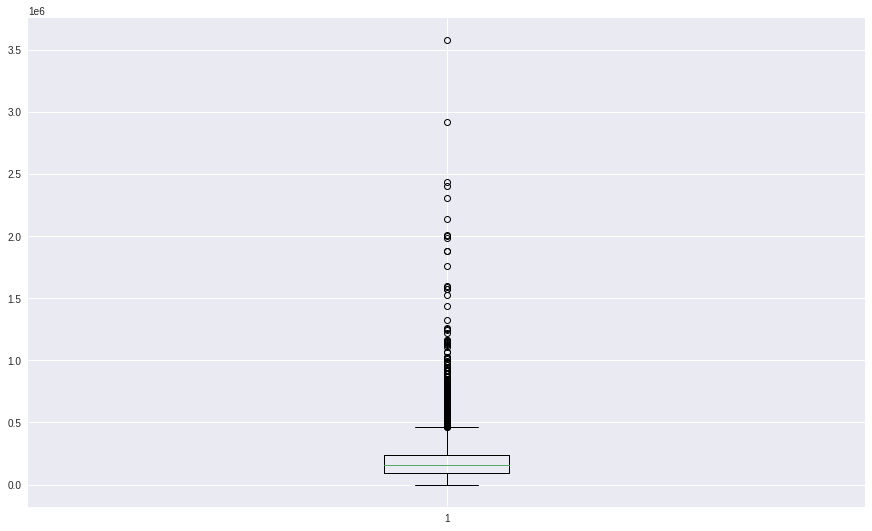

In [189]:
plt.style.use("seaborn")
fig,ax=plt.subplots(figsize=(15,9))
ax.boxplot([data["Average Fees"]])
plt.show()

In [190]:
data['Total Faculty'] = data['Total Faculty'].astype(str)

In [191]:
tes=data[0:30]

ANALYZING NUMBER OF FACULTIES IN PRIVATE AND GOVERNMENT COLLEGES.

Using scatter plot on a part of dataset, which shows number of faculties in government and private colleges.

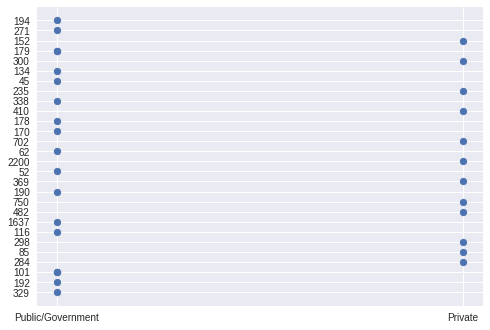

In [192]:
plt.scatter(tes['College Type'],tes['Total Faculty'])

FINDING THE BEST ENGINEERING COLLEGE AS PER THE RATING.

Using 'max()' function to find the maximum rating of an Engineering College given by some verified authority.

In [193]:
a=data['Rating'].max()

In [194]:
data.loc[data['Rating'] == a]

,College Name,Genders Accepted,Campus Size,Total Student Enrollments,Total Faculty,Established Year,Rating,University,Courses,Facilities,City,State,Country,College Type,Average Fees
5,BMS College of Engineering,Co-Ed,15 Acres,5610,298,1946,3.83,"Visvesvaraya Technological University, Belagavi","BE Civil Engineering, BE Computer Science and ...","Boys Hostel, Girls Hostel, Gym, Library, Sport...",Bengaluru,Karnataka,India,Private,71558.67


ANALYZING THE NUMBER OF GIRLS COLLEGES, BOYS COLLEGES AND CO-ED COLLEGES.

Using Seaborn to count the number of students per category for a categorical variable i.e. Gender and plotting it in the form of Bar Graph.

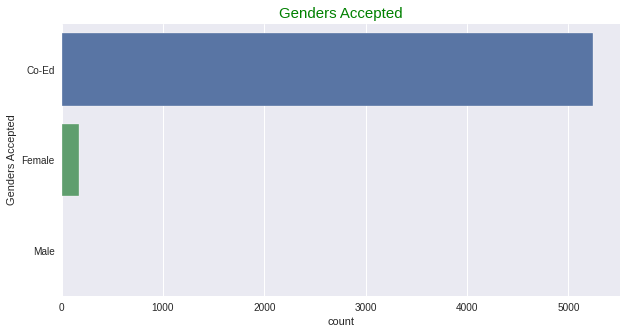

In [195]:
plt.figure(figsize=(10,5))
sns.countplot(y="Genders Accepted",data=data)
plt.title('Genders Accepted', color='green',
         fontsize=15);

In [219]:
data3

,country_name,country_code,university_name,university_rank,program_name,program_type,deadline,duration,language,tution_1_currency,tution_1_money,tution_1_type,tution_2_currency,tution_2_money,tution_2_type,tuition_price_specification,start_date,ielts_score,structure,academic_req,facts,city,program_url
0,Armenia,ARM,American University of Armenia,NaN,Economics,MSc,2004-07-18T00:00:00Z,NaN,English,EUR,6442.0,International,EUR,2108.0,EU/EEA,Tuition (Year),2018-09-01 00:00:00,6.5,['Quantitative Methods for Economists (Mathema...,"<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-09-01 00:00:00 You can...,['Yerevan'],http://www.mastersportal.eu/studies/71101/econ...
1,Armenia,ARM,American University of Armenia,NaN,Political Science and International Affairs,Master,2031-07-18T00:00:00Z,24 months,English,EUR,6300.0,International,EUR,2500.0,National,Tuition (Year),2018-08-22 00:00:00,6.5,NaN,"<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-08-22 00:00:00 You can...,['Yerevan'],http://www.mastersportal.eu/studies/71085/poli...
2,Armenia,ARM,American University of Armenia,NaN,Business Administration,MBA,2004-07-18T00:00:00Z,NaN,English,EUR,7497.0,International,EUR,2499.0,EU/EEA,Tuition (Year),2018-09-01 00:00:00,6.5,['Managers with practical knowledge of account...,"<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-09-01 00:00:00 You can...,['Yerevan'],http://www.mastersportal.eu/studies/71102/busi...
3,Armenia,ARM,American University of Armenia,NaN,Computer and Information Science,MSc,NaN,24 months,English,EUR,6300.0,International,EUR,2500.0,National,Tuition (Year),NaN,6.5,['Introduction to Object-Oriented Programming'...,"<section id=""AcademicRequirements""> <h2>Academ...",['Deadline and start date Application deadline...,['Yerevan'],http://www.mastersportal.eu/studies/71104/comp...
4,Armenia,ARM,American University of Armenia,NaN,Industrial Engineering and Systems Management,MEng,2031-07-18T00:00:00Z,24 months,English,EUR,6300.0,International,EUR,2500.0,National,Tuition (Year),2018-08-22 00:00:00,6.5,"['Probability Theory', 'Analysis and Design of...","<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-08-22 00:00:00 You can...,['Yerevan'],http://www.mastersportal.eu/studies/71103/indu...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60420,Viet Nam,VNM,Engineering Institute of Technology,NaN,Electrical Systems,MEng,2031-05-18T00:00:00Z,NaN,English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-26 00:00:00,6.5,"['Power Generation', 'Underground Power System...","<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-06-26 00:00:00 You can...,NaN,http://www.mastersportal.eu/studies/155433/ele...
60421,Viet Nam,VNM,Engineering Institute of Technology,NaN,Industrial Automation,MEng,2031-05-18T00:00:00Z,24 months,English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-26 00:00:00,6.5,"[\'Power Engineering\', \'Programmable Logic C...","<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-06-26 00:00:00 You can...,['Perth'],http://www.mastersportal.eu/studies/75623/indu...
60422,Viet Nam,VNM,Engineering Institute of Technology,NaN,Renewable Energy Technologies,Postgraduate Certificate,2009-05-18T00:00:00Z,6 months,English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-05-16 00:00:00,NaN,['Unit 1 - Fundamentals and General Distributi...,"<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-05-16 00:00:00 You can...,NaN,http://www.mastersportal.eu/studies/75749/rene...
60423,Viet Nam,VNM,Engineering Institute of Technology,NaN,Safety,MEng,2031-05-18T00:00:00Z,NaN,English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-26 00:00:00,6.5,['Introduction to Safety Engineering and Risk ...,"<section id=""AcademicRequirements""> <h2>Academ...",['Starting in 2018-06-26 00:00:00 You can...,NaN,http://www.mastersportal.eu/studies/155424/saf...


ANALYSING THE NUMBER OF STUDENTS APPLIED FOR GATE EXAMINATION.

Box plot is used here for better understanding of the column "Applied". It gives us idea about how many students actually applied for the GATE exam".

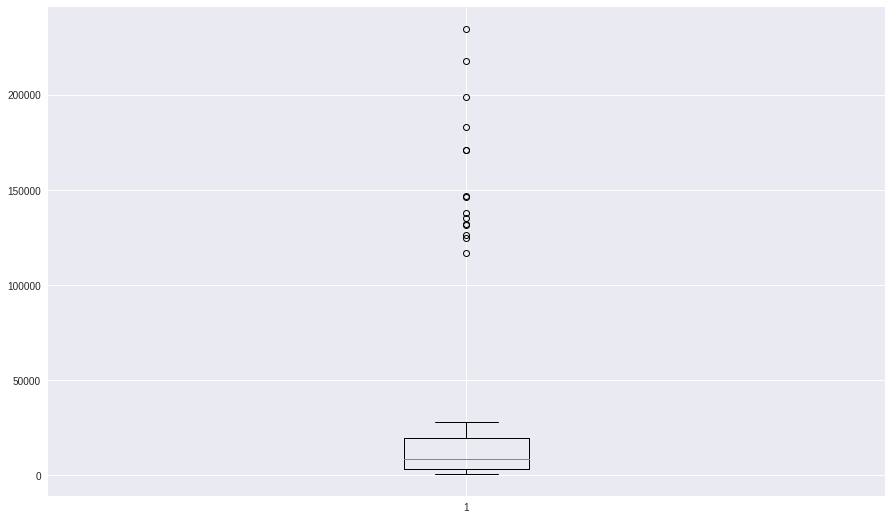

In [197]:
plt.style.use("seaborn")
fig,ax=plt.subplots(figsize=(15,9))
ax.boxplot([data1["Applied"]])
plt.show()

ANALYSING THE NUMBER OF STUDENTS APPEARED FOR GATE EXAMINATION.

Box plot is used here for better understanding of the column "Appeared". It gives us idea about how many students actually appeared for the GATE exam".

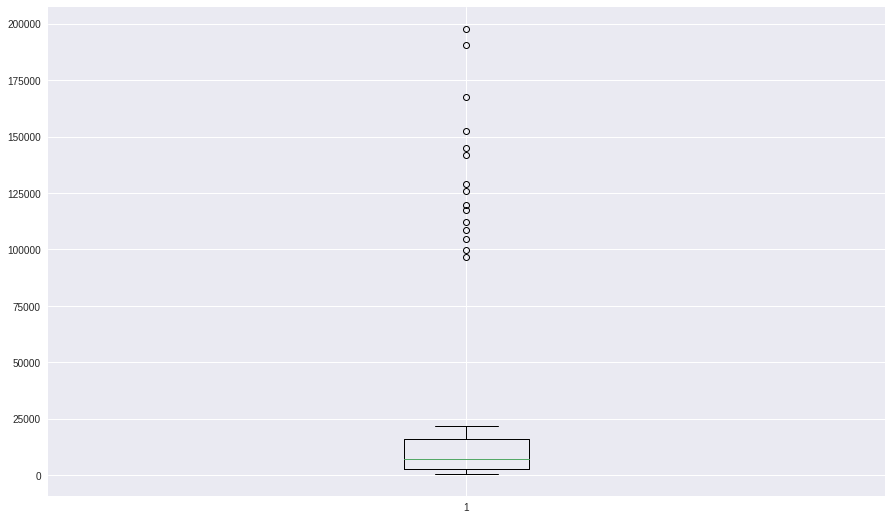

In [209]:
plt.style.use("seaborn")
fig,ax=plt.subplots(figsize=(15,9))
ax.boxplot([data1["Appeared"]])
plt.show()

In [224]:
temda=data2

In [225]:
temda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  93 non-null     int64  
 1   Sr No       93 non-null     int64  
 2   Paper Name  93 non-null     object 
 3   Paper Code  93 non-null     object 
 4   GEN         93 non-null     float64
 5   OBC         93 non-null     float64
 6   SC/ST       93 non-null     float64
 7   Year        93 non-null     int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 5.9+ KB


In [229]:
temda=temda.drop(['Unnamed: 0','Sr No','Paper Name','Paper Code'],axis='columns')

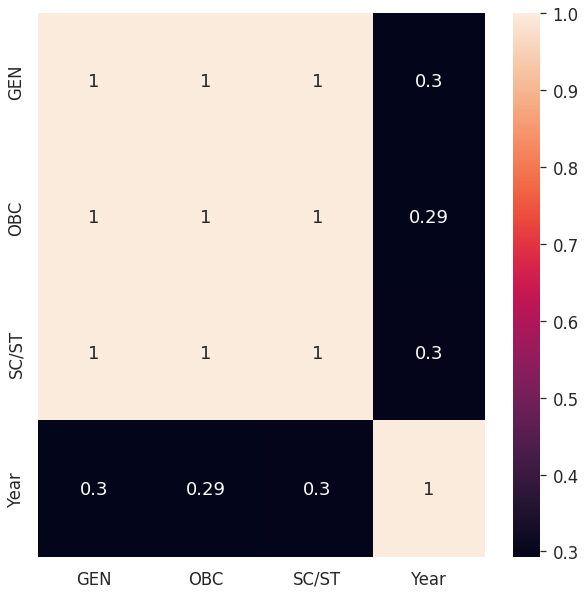

In [230]:
correlation=temda.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True)

In [198]:
data1

,Unnamed: 0,Paper Code,Paper Name,Applied,Appeared,Year
0,0,AE,Aerospace Engineering,4639,3697,2019
1,1,AG,Agricultural Engineering,2088,1848,2019
2,2,AR,Architecture and Planning,11208,9105,2019
3,3,BT,Biotechnology,11295,9348,2019
4,4,CE,Civil Engineering,170999,145064,2019
...,...,...,...,...,...,...
65,65,PH,Physics,12243,9910,2016
66,66,PI,Production and Industrial Engineering,4131,3378,2016
67,67,TF,Textile Engineering and Fibre Science,1587,1406,2016
68,68,XE,Engineering Sciences,3722,3074,2016


In [201]:
tempdata=data1

In [205]:
tempdata=tempdata.drop(['Unnamed: 0','Paper Code','Paper Name'],axis='columns')

HEAT MAP SHOWING CORRELATION BETWEEN THE NUMBER OF STUDENTS APPLIED AND NUMBER OF STUDENTS APPEARED FOR THE GATE EXAM.

Using heatmap to show the correaltion between the number of students applied for GATE Exam and number of students actually appeared for the GATE exam.

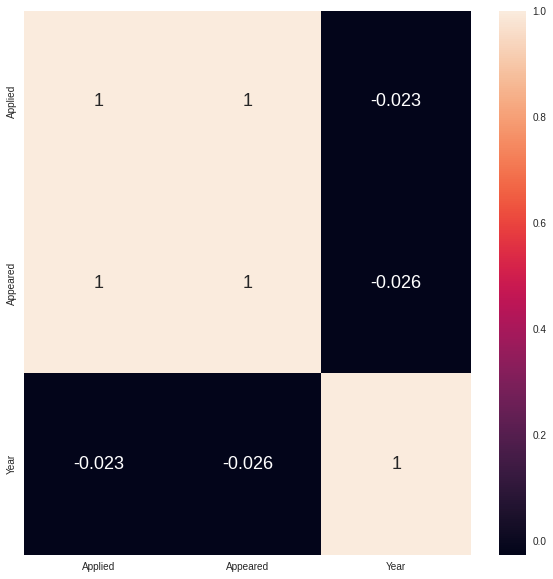

In [206]:
correlation=tempdata.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True)

In [207]:
tempdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Applied   70 non-null     int64
 1   Appeared  70 non-null     int64
 2   Year      70 non-null     int64
dtypes: int64(3)
memory usage: 1.8 KB


In [210]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

TESTING THE ACCURACY:

In [211]:
data11=data1.drop(['Paper Code','Paper Name'],axis='columns')

In [212]:
X=data11.iloc[:,:-1]
Y=data11.iloc[:,-1]

In [213]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [220]:
print(X_train)

    Unnamed: 0  Applied  Appeared
33          33   135426    117443
55          55   183152    152318
68          68     3722      3074
62          62     2753      2230
43          43     3457      2915
4            4   170999    145064
65          65    12243      9910
50          50    11161      9124
2            2    11208      9105
40          40     4167      3494
11          11     7100      5899
3            3    11295      9348
54          54    18434     14966
45          45     3783      3169
10          10     1460      1092
41          41     1964      1622
49          49     6806      5812
53          53   131803    108495
57          57      981       727
32          32   171160    141665
14          14   198841    167376
67          67     1587      1406
19          19     3503      2890
29          29    17329     14542
52          52    18642     15495
35          35     6444      5537
18          18    20216     16296
0            0     4639      3697
15          15

In [214]:
print(Y_train)

33    2017
55    2016
68    2016
62    2016
43    2017
4     2019
65    2016
50    2016
2     2019
40    2017
11    2019
3     2019
54    2016
45    2017
10    2019
41    2017
49    2016
53    2016
57    2016
32    2017
14    2019
67    2016
19    2019
29    2017
52    2016
35    2017
18    2019
0     2019
15    2019
5     2019
16    2019
20    2019
66    2016
8     2019
13    2019
25    2017
37    2017
17    2019
60    2016
46    2017
63    2016
39    2017
38    2017
1     2019
58    2016
12    2019
61    2016
24    2017
6     2019
23    2019
36    2017
21    2019
9     2019
64    2016
47    2016
44    2017
Name: Year, dtype: int64


Accuracy  100.0


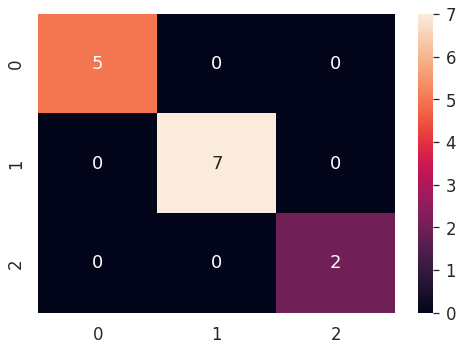

In [215]:
DT = DecisionTreeClassifier()
DT.fit(X_train, Y_train)
Y_pred = DT.predict(X_test)
print("Accuracy ", DT.score(X_test, Y_test)*100)
sns.set(font_scale=1.5)
cm=confusion_matrix(Y_pred,Y_test)
sns.heatmap(cm,annot=True)

Accuracy 35.714285714285715


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



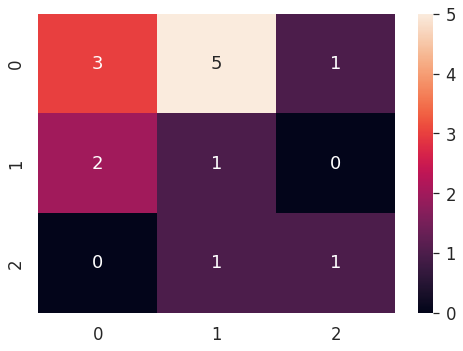

In [216]:
LR=LogisticRegression()
LR.fit(X_train,Y_train)
Y_pred=LR.predict(X_test)
print("Accuracy",LR.score(X_test,Y_test)*100)
sns.set(font_scale=1.5)
cm=confusion_matrix(Y_pred,Y_test)
sns.heatmap(cm,annot=True)